# 🌊 Flood Prediction — Early Warning System
**Machine Learning Pipeline | Decision Tree · Random Forest · KNN · XGBoost**

---
This notebook follows the complete ML lifecycle:
1. Data Collection & Loading
2. Visualisation & Analysis (Univariate · Multivariate · Descriptive)
3. Data Pre-Processing
4. Model Building & Evaluation
5. Best Model Export (.pkl)

---
## Epic 1 — Data Collection
### Story 1 · Load the flood prediction dataset

---
## Epic 2 — Visualising & Analysing the Data
### Story 1 · Import all required libraries

In [1]:
# ── Numerical & Data ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

# ── Scikit-learn: Preprocessing ───────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Scikit-learn: Models ──────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# ── XGBoost ───────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Evaluation ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# ── Model Persistence ─────────────────────────────────────────
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Styling ───────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

print('✅ All libraries imported successfully!')
print(f'   NumPy   {np.__version__}')
print(f'   Pandas  {pd.__version__}')
print(f'   Seaborn {sns.__version__}')

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!
   NumPy   2.5.0
   Pandas  3.0.3
   Seaborn 0.13.2


### Story 2 · Read & explore the dataset

In [2]:
df = pd.read_csv('flood_data.csv')

print('=' * 55)
print(f'  Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns')
print('=' * 55)
print('\n📋 First 5 rows:')
df.head()

  Dataset Shape : 2500 rows × 19 columns

📋 First 5 rows:


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,FLOODS
0,1901,24.0,30.0,22.4,83.0,43.0,203.1,285.0,364.4,208.1,91.9,36.4,8.3,1399.5,53.9,148.3,1060.5,136.7,1
1,1902,16.3,35.6,21.8,47.7,53.4,119.0,292.7,301.7,204.7,123.0,33.2,32.1,1281.4,51.9,123.0,918.2,188.3,1
2,1903,25.8,17.4,0.0,61.6,45.3,133.3,299.5,384.6,141.3,106.2,24.4,15.6,1254.8,43.1,106.8,958.7,146.1,1
3,1904,36.3,13.4,24.1,47.2,65.1,121.1,361.3,342.0,220.1,103.8,32.9,30.2,1397.6,49.7,136.3,1044.5,167.0,1
4,1905,15.2,6.8,43.2,30.3,95.5,167.4,242.7,244.4,112.5,89.7,42.8,11.8,1102.3,22.0,169.0,767.0,144.3,1


In [3]:
print('\n📋 Dataset Info:')
print('-' * 45)
df.info()


📋 Dataset Info:
---------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     2500 non-null   int64  
 1   JAN      2500 non-null   float64
 2   FEB      2500 non-null   float64
 3   MAR      2500 non-null   float64
 4   APR      2500 non-null   float64
 5   MAY      2500 non-null   float64
 6   JUN      2500 non-null   float64
 7   JUL      2500 non-null   float64
 8   AUG      2500 non-null   float64
 9   SEP      2500 non-null   float64
 10  OCT      2500 non-null   float64
 11  NOV      2500 non-null   float64
 12  DEC      2500 non-null   float64
 13  ANNUAL   2500 non-null   float64
 14  Jan-Feb  2500 non-null   float64
 15  Mar-May  2500 non-null   float64
 16  Jun-Sep  2500 non-null   float64
 17  Oct-Dec  2500 non-null   float64
 18  FLOODS   2500 non-null   int64  
dtypes: float64(17), int64(2)
memory usage:

In [4]:
# Missing value check
missing = df.isnull().sum()
print('🔍 Missing Values per Column:')
print('-' * 35)
if missing.sum() == 0:
    print('  ✅ No missing values found!')
else:
    print(missing[missing > 0])

# Target distribution
print('\n🎯 Target Variable — FLOODS:')
print('-' * 35)
vc = df['FLOODS'].value_counts()
print(f'  No Flood (0) : {vc[0]:>5}  ({vc[0]/len(df)*100:.1f}%)')
print(f'  Flood    (1) : {vc[1]:>5}  ({vc[1]/len(df)*100:.1f}%)')

🔍 Missing Values per Column:
-----------------------------------
  ✅ No missing values found!

🎯 Target Variable — FLOODS:
-----------------------------------
  No Flood (0) :   351  (14.0%)
  Flood    (1) :  2149  (86.0%)


### Story 3 · Univariate Analysis

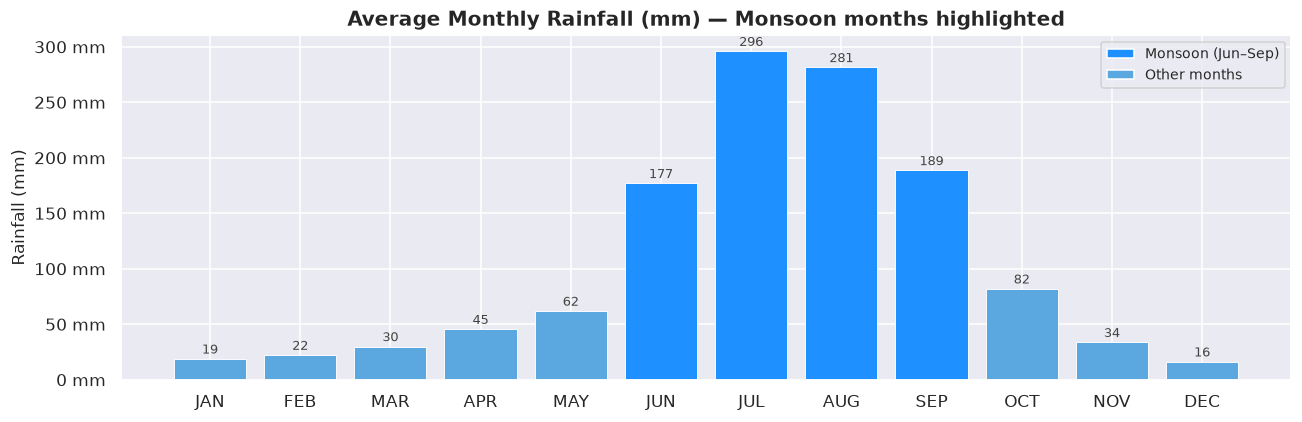

  Peak month : JUL (295.9 mm)
  Low  month : DEC (16.1 mm)


In [5]:
# 3.1  Average Monthly Rainfall Bar Chart
months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
means  = df[months].mean()
colors = ['#1E90FF' if m in ('JUN','JUL','AUG','SEP') else '#5BA8E0' for m in months]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(months, means, color=colors, edgecolor='white', linewidth=0.6)
ax.set_title('Average Monthly Rainfall (mm) — Monsoon months highlighted', fontweight='bold')
ax.set_ylabel('Rainfall (mm)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f mm'))

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8.5, color='#444')

legend_elements = [
    Patch(facecolor='#1E90FF', label='Monsoon (Jun–Sep)'),
    Patch(facecolor='#5BA8E0', label='Other months')
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

print(f'  Peak month : {means.idxmax()} ({means.max():.1f} mm)')
print(f'  Low  month : {means.idxmin()} ({means.min():.1f} mm)')

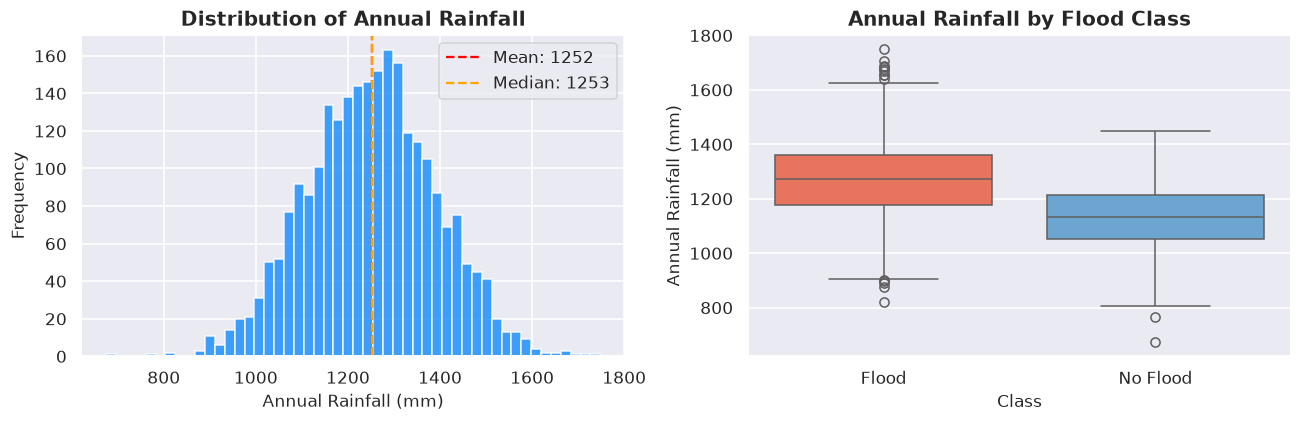

  Skewness of ANNUAL : 0.0122  (approx. symmetric)


In [6]:
# 3.2  Distribution of Annual Rainfall
flood_labels = {0: 'No Flood', 1: 'Flood'}
df['Flood_Label'] = df['FLOODS'].map(flood_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['ANNUAL'], bins=50, color='#1E90FF', edgecolor='white', alpha=0.85)
axes[0].axvline(df['ANNUAL'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["ANNUAL"].mean():.0f}')
axes[0].axvline(df['ANNUAL'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {df["ANNUAL"].median():.0f}')
axes[0].set_title('Distribution of Annual Rainfall', fontweight='bold')
axes[0].set_xlabel('Annual Rainfall (mm)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(data=df, x='Flood_Label', y='ANNUAL', ax=axes[1],
            palette={'No Flood': '#5BA8E0', 'Flood': '#FF6347'})
axes[1].set_title('Annual Rainfall by Flood Class', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Annual Rainfall (mm)')

plt.tight_layout()
plt.show()

skew = df['ANNUAL'].skew()
print(f'  Skewness of ANNUAL : {skew:.4f}  ({"right-skewed" if skew > 0.5 else "approx. symmetric"})')

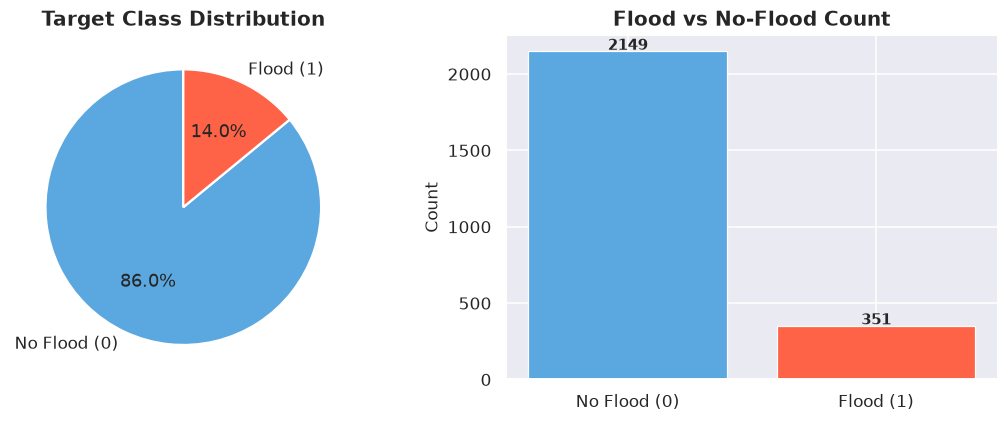

  Class ratio — No Flood : Flood = 351 : 2149


In [7]:
# 3.3  Target Class Balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df['FLOODS'].value_counts()
labels = ['No Flood (0)', 'Flood (1)']
colors_pie = ['#5BA8E0', '#FF6347']

axes[0].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors_pie,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Target Class Distribution', fontweight='bold')

axes[1].bar(labels, counts, color=colors_pie, edgecolor='white', linewidth=0.8)
axes[1].set_title('Flood vs No-Flood Count', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'  Class ratio — No Flood : Flood = {counts[0]} : {counts[1]}')

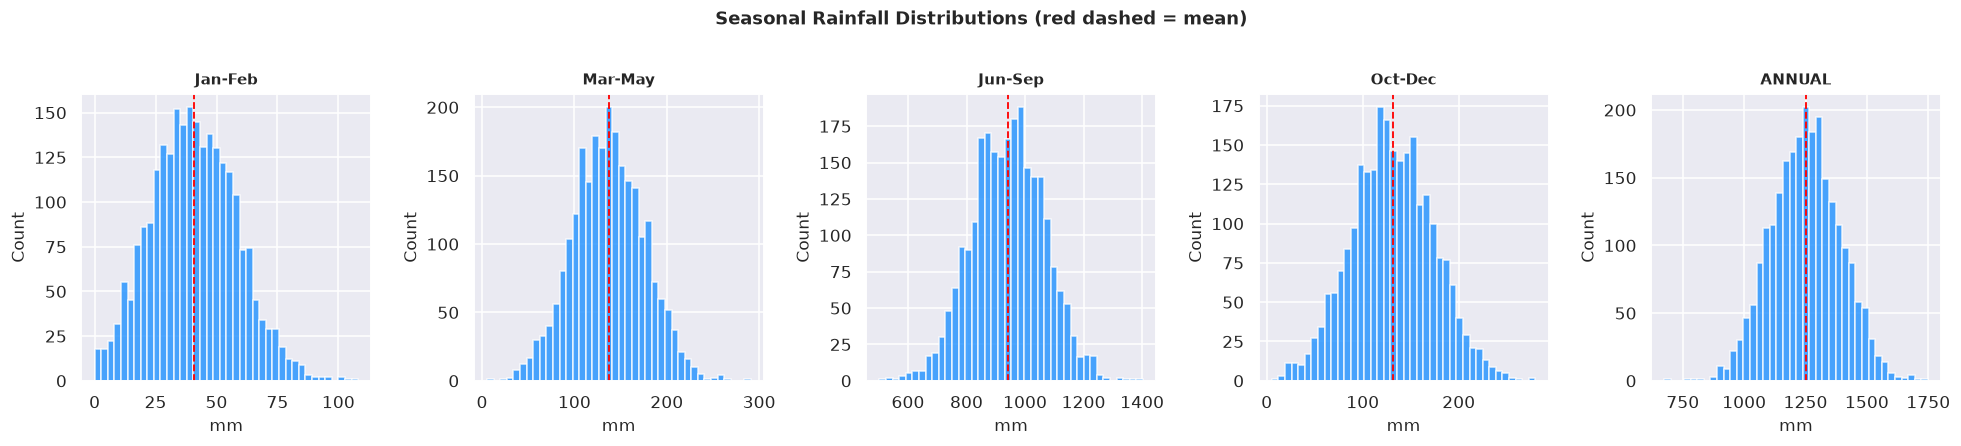

In [8]:
# 3.4  Distribution of all seasonal features
seasonal = ['Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'ANNUAL']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, seasonal):
    ax.hist(df[col], bins=40, color='#1E90FF', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('mm')
    ax.set_ylabel('Count')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2)

plt.suptitle('Seasonal Rainfall Distributions (red dashed = mean)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Story 4 · Multivariate Analysis

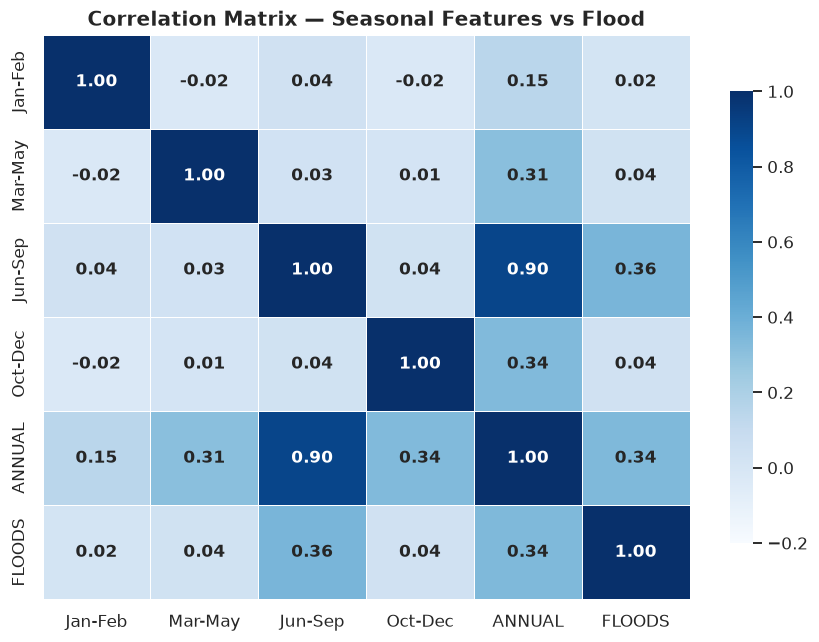


📌 Top correlations with FLOODS:
  Jun-Sep      r = +0.358  ██████████
  ANNUAL       r = +0.340  ██████████
  Oct-Dec      r = +0.042  █
  Mar-May      r = +0.036  █
  Jan-Feb      r = +0.020  


In [9]:
# 4.1  Correlation Heatmap
features_for_corr = ['Jan-Feb','Mar-May','Jun-Sep','Oct-Dec','ANNUAL','FLOODS']
corr_matrix = df[features_for_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'},
            vmin=-0.2, vmax=1.0, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Seasonal Features vs Flood', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\n📌 Top correlations with FLOODS:')
corr_flood = corr_matrix['FLOODS'].drop('FLOODS').sort_values(ascending=False)
for feat, val in corr_flood.items():
    bar = '█' * int(abs(val) * 30)
    print(f'  {feat:<12} r = {val:+.3f}  {bar}')

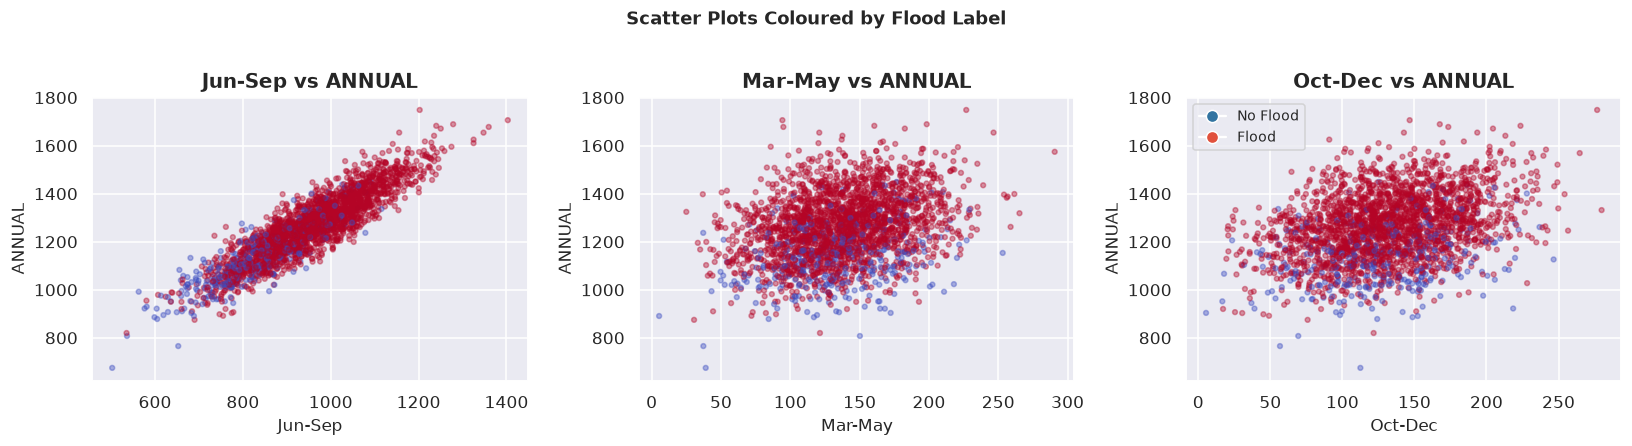

In [10]:
# 4.2  Scatter Plots — key features vs ANNUAL
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('Jun-Sep', 'ANNUAL'), ('Mar-May', 'ANNUAL'), ('Oct-Dec', 'ANNUAL')]

for ax, (x_feat, y_feat) in zip(axes, pairs):
    scatter = ax.scatter(df[x_feat], df[y_feat],
                         c=df['FLOODS'], cmap='coolwarm', alpha=0.4, s=10)
    ax.set_xlabel(x_feat); ax.set_ylabel(y_feat)
    ax.set_title(f'{x_feat} vs {y_feat}', fontweight='bold')

legend_el = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3274A1', markersize=8, label='No Flood'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E1513D', markersize=8, label='Flood')
]
axes[2].legend(handles=legend_el, loc='upper left', fontsize=9)
plt.suptitle('Scatter Plots Coloured by Flood Label', fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

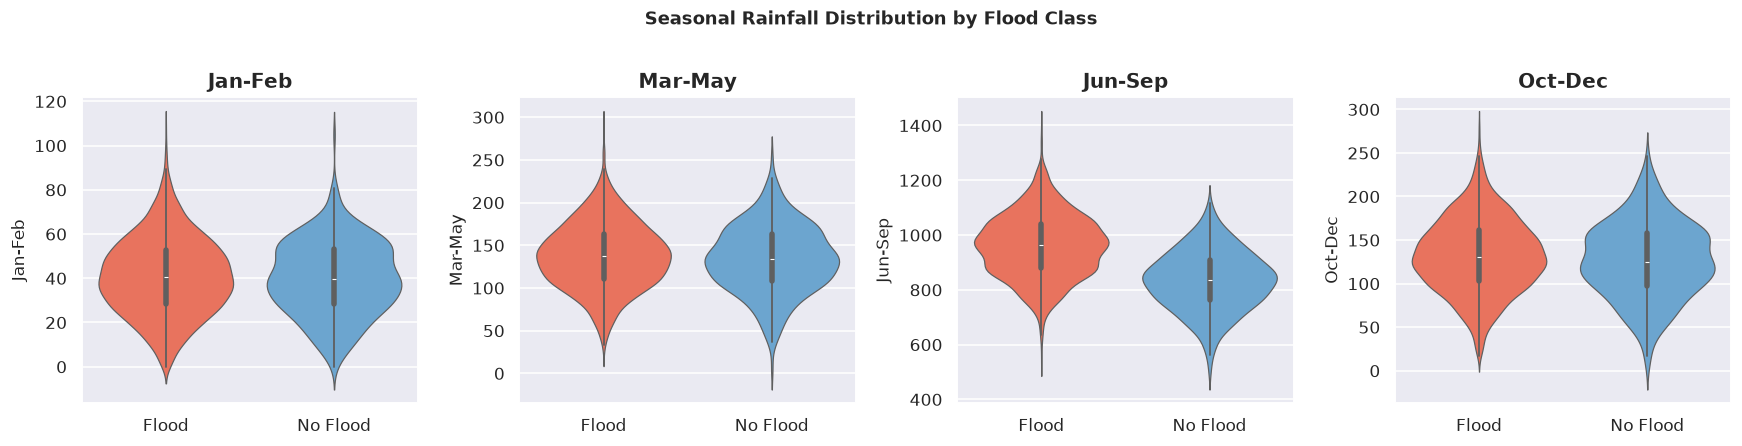

In [11]:
# 4.3  Seasonal rainfall by flood label — Violin plots
seasonal_feats = ['Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, feat in zip(axes, seasonal_feats):
    sns.violinplot(data=df, x='Flood_Label', y=feat, ax=ax,
                   palette={'No Flood': '#5BA8E0', 'Flood': '#FF6347'},
                   inner='box', linewidth=0.8)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Seasonal Rainfall Distribution by Flood Class',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

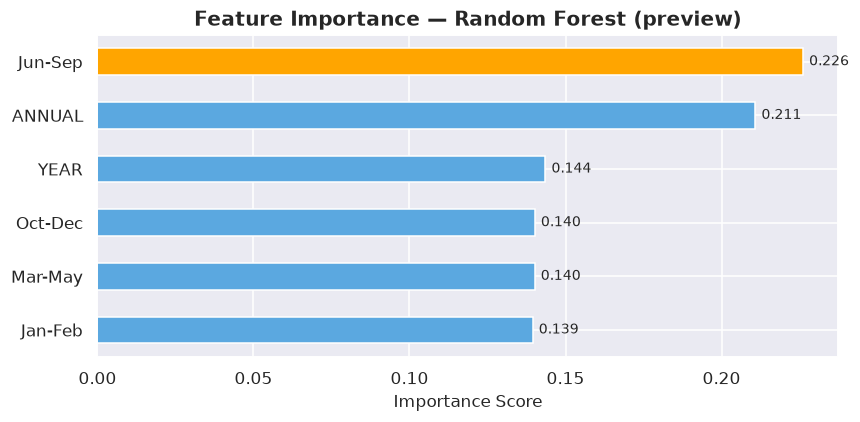

In [12]:
# 4.4  Feature Importance preview (Random Forest)
_X = df[['Jan-Feb','Mar-May','Jun-Sep','Oct-Dec','ANNUAL','YEAR']]
_y = df['FLOODS']
_rf = RandomForestClassifier(n_estimators=100, random_state=42)
_rf.fit(_X, _y)

importances = pd.Series(_rf.feature_importances_, index=_X.columns).sort_values()
colors_imp = ['#FFA500' if i == importances.index[-1] else '#5BA8E0' for i in importances.index]

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot.barh(ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importance — Random Forest (preview)', fontweight='bold')
ax.set_xlabel('Importance Score')
for patch, val in zip(ax.patches, importances):
    ax.text(val + 0.002, patch.get_y() + patch.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Story 5 · Descriptive Statistical Analysis

In [13]:
# 5.1  Full statistical summary with skewness & kurtosis
desc = df.drop(columns=['FLOODS','Flood_Label']).describe().T
desc['skewness'] = df.drop(columns=['FLOODS','Flood_Label']).skew()
desc['kurtosis'] = df.drop(columns=['FLOODS','Flood_Label']).kurt()
desc = desc.round(2)

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
print('📊 Descriptive Statistics:')
print('=' * 95)
print(desc.to_string())

📊 Descriptive Statistics:
          count     mean     std     min      25%      50%      75%     max  skewness  kurtosis
YEAR     2500.0  3150.50  721.83  1901.0  2525.75  3150.50  3775.25  4400.0      0.00     -1.20
JAN      2500.0    18.69   11.22     0.0    10.48    18.30    26.20    64.2      0.29     -0.30
FEB      2500.0    22.11   13.29     0.0    12.10    21.90    31.10    77.0      0.26     -0.32
MAR      2500.0    29.88   17.63     0.0    17.00    29.30    42.30    93.5      0.30     -0.29
APR      2500.0    45.36   21.51     0.0    30.60    45.25    59.80   119.3      0.09     -0.28
MAY      2500.0    61.82   27.09     0.0    43.48    61.35    80.00   156.6      0.07     -0.16
JUN      2500.0   176.87   55.70     0.0   138.78   176.95   214.40   363.6      0.02      0.02
JUL      2500.0   295.92   70.44    40.5   248.55   296.20   343.90   608.5     -0.01      0.09
AUG      2500.0   281.35   68.04    17.8   234.80   281.70   328.50   548.1     -0.00      0.08
SEP      2500.

In [14]:
# 5.2  Group statistics by flood label
group_stats = df.groupby('Flood_Label')[['ANNUAL','Jun-Sep','Mar-May','Jan-Feb','Oct-Dec']] \
                .agg(['mean','std']).round(1)
print('📊 Group Statistics (Flood vs No Flood):')
print('=' * 70)
print(group_stats.to_string())

📊 Group Statistics (Flood vs No Flood):
             ANNUAL        Jun-Sep        Mar-May       Jan-Feb       Oct-Dec      
               mean    std    mean    std    mean   std    mean   std    mean   std
Flood_Label                                                                        
Flood        1271.2  133.0   960.4  115.7   137.6  38.4    40.9  17.5   132.3  42.4
No Flood     1134.6  121.1   833.9  107.6   133.6  39.3    40.0  16.6   127.1  43.6


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

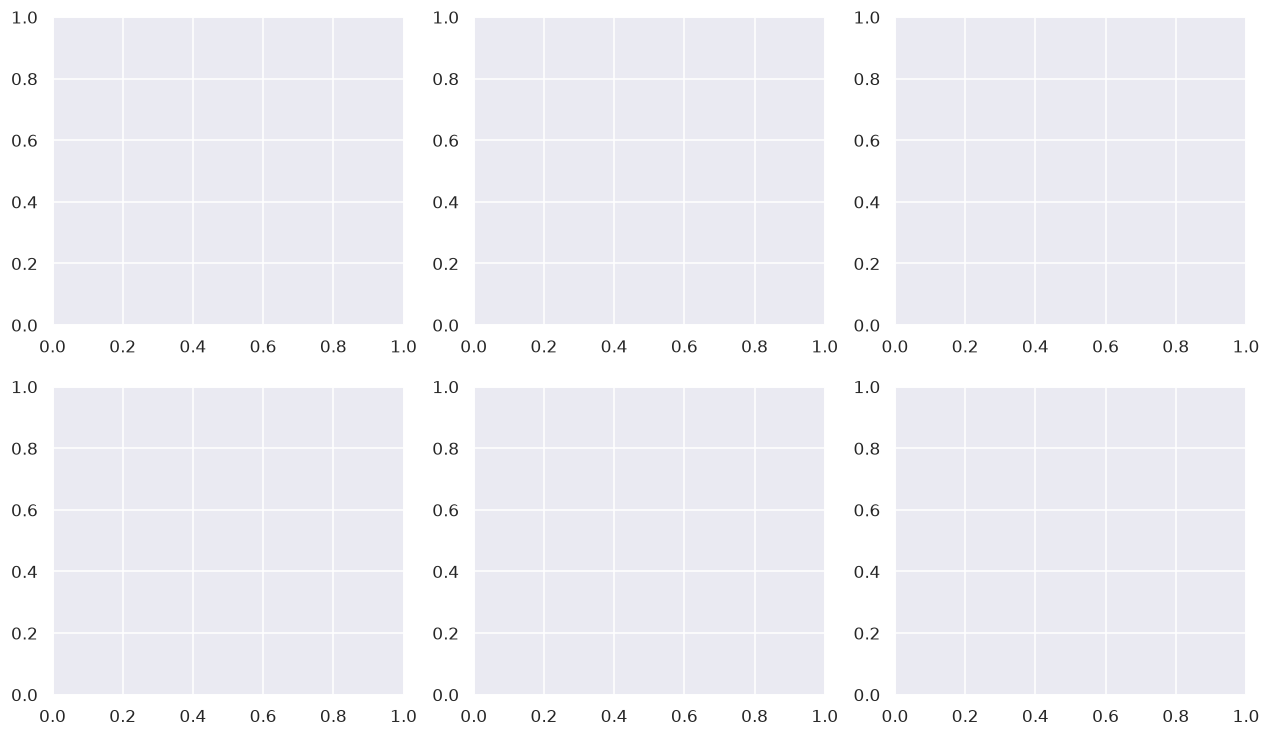

In [16]:
# 5.3  Box plots — descriptive spread
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
feats_box = ['JAN','APR','JUL','Oct-Dec','Mar-May','ANNUAL']

for ax, feat in zip(axes, feats_box):
    bp = ax.boxplot([df[df['FLOODS']==0][feat], df[df['FLOODS']==1][feat]],
                    labels=['No Flood','Flood'], patch_artist=True,
                    medianprops={'color':'red','linewidth':2})
    bp['boxes'][0].set_facecolor('#5BA8E0')
    bp['boxes'][1].set_facecolor('#FF6347')
    ax.set_title(f'{feat}', fontweight='bold')
    ax.set_ylabel('mm')

plt.suptitle('Box Plots: Rainfall Spread by Flood Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

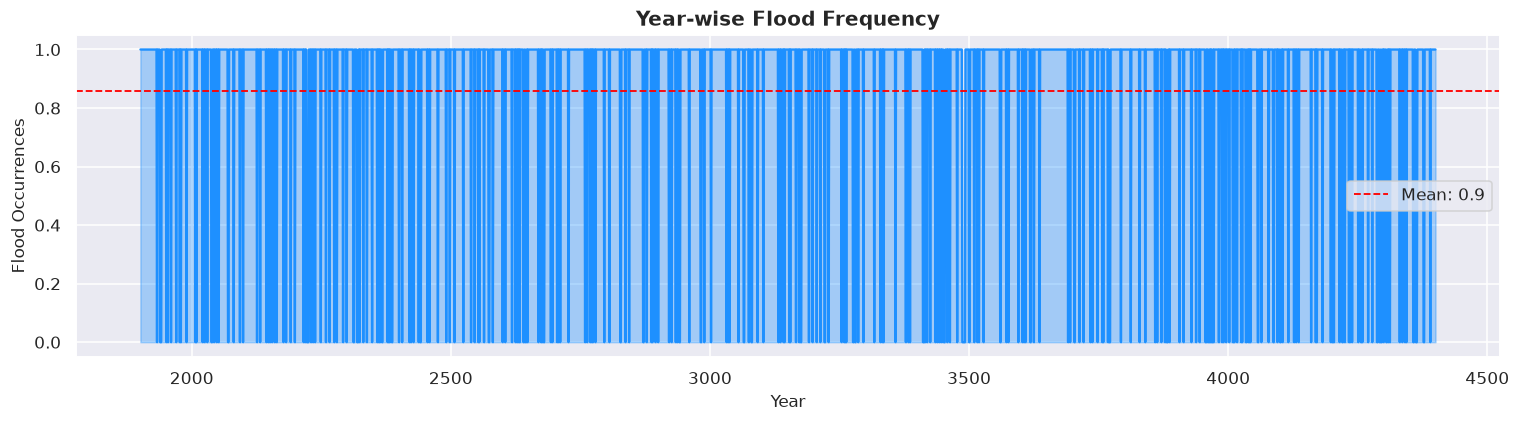

In [17]:
# 5.4  Year-wise flood frequency
flood_by_year = df.groupby('YEAR')['FLOODS'].sum().reset_index()
flood_by_year.columns = ['YEAR', 'FloodCount']

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(flood_by_year['YEAR'], flood_by_year['FloodCount'], alpha=0.35, color='#1E90FF')
ax.plot(flood_by_year['YEAR'], flood_by_year['FloodCount'], color='#1E90FF', linewidth=1.5)
ax.set_title('Year-wise Flood Frequency', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Flood Occurrences')
ax.axhline(flood_by_year['FloodCount'].mean(), color='red', linestyle='--', linewidth=1.2,
           label=f"Mean: {flood_by_year['FloodCount'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

---
## Epic 3 — Data Pre-Processing
### Story 1 · Handle missing values

In [18]:
print('🔍 Missing Value Check:')
print('-' * 40)
missing = df.isnull().sum()
if missing.sum() == 0:
    print('  ✅ No missing values — dataset is complete!')
else:
    print(missing[missing > 0])
    # Fill numeric columns with median
    for col in df.select_dtypes(include='number').columns:
        df[col].fillna(df[col].median(), inplace=True)
    print('  ✅ Missing values filled with column median.')

🔍 Missing Value Check:
----------------------------------------
  ✅ No missing values — dataset is complete!


### Story 2 · Detect and treat outliers

In [19]:
# IQR-based outlier detection (report only — not capped, as extremes are real flood signals)
numeric_cols = ['ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']
print('📊 Outlier Detection (IQR method):')
print('-' * 50)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'  {col:<12}  Bounds: [{lower:.1f}, {upper:.1f}]  Outliers: {n_out}')

print('\n  ℹ️  Extreme values retained — they carry genuine flood signal.')

📊 Outlier Detection (IQR method):
--------------------------------------------------
  ANNUAL        Bounds: [873.6, 1628.2]  Outliers: 13
  Jan-Feb       Bounds: [-8.2, 89.4]  Outliers: 9
  Mar-May       Bounds: [30.4, 243.3]  Outliers: 11
  Jun-Sep       Bounds: [601.6, 1285.0]  Outliers: 13
  Oct-Dec       Bounds: [15.3, 247.0]  Outliers: 10

  ℹ️  Extreme values retained — they carry genuine flood signal.


### Story 3 · Encode categorical variables

In [20]:
# All features are already numeric; FLOODS is binary (0/1) — no encoding needed
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('🔤 Categorical columns:', cat_cols if cat_cols else 'None — all features are numeric ✅')

🔤 Categorical columns: ['Flood_Label']


### Story 4 · Train / Test Split

In [21]:
feature_cols = ['ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'YEAR']
X = df[feature_cols]
y = df['FLOODS']

# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=' * 45)
print(f'  Training samples : {X_train.shape[0]}')
print(f'  Testing  samples : {X_test.shape[0]}')
print(f'  Features         : {X_train.shape[1]}')
print('=' * 45)
print(f'  Train flood rate : {y_train.mean()*100:.1f}%')
print(f'  Test  flood rate : {y_test.mean()*100:.1f}%')
print('  ✅ Stratified split preserves class ratio')

  Training samples : 2000
  Testing  samples : 500
  Features         : 6
  Train flood rate : 86.0%
  Test  flood rate : 86.0%
  ✅ Stratified split preserves class ratio


### Story 5 · Feature Scaling

In [22]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('✅ StandardScaler applied.')
print(f'   Feature means (train) ≈ {X_train_sc.mean(axis=0).round(4)}')
print(f'   Feature stds  (train) ≈ {X_train_sc.std(axis=0).round(4)}')

✅ StandardScaler applied.
   Feature means (train) ≈ [ 0.  0. -0.  0.  0.  0.]
   Feature stds  (train) ≈ [1. 1. 1. 1. 1. 1.]


---
## Epic 4 — Model Building
### Story 1 · Decision Tree

In [23]:
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

print('🌳 Decision Tree')
print(f'   Accuracy : {accuracy_score(y_test, dt_pred)*100:.2f}%')
print(f'   ROC-AUC  : {roc_auc_score(y_test, dt_prob):.4f}')
print()
print(classification_report(y_test, dt_pred, target_names=['No Flood','Flood']))

🌳 Decision Tree
   Accuracy : 81.80%
   ROC-AUC  : 0.6309

              precision    recall  f1-score   support

    No Flood       0.28      0.19      0.22        70
       Flood       0.87      0.92      0.90       430

    accuracy                           0.82       500
   macro avg       0.58      0.55      0.56       500
weighted avg       0.79      0.82      0.80       500



### Story 2 · Random Forest

In [24]:
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print('🌲 Random Forest')
print(f'   Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%')
print(f'   ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=['No Flood','Flood']))

🌲 Random Forest
   Accuracy : 85.40%
   ROC-AUC  : 0.7614

              precision    recall  f1-score   support

    No Flood       0.45      0.19      0.26        70
       Flood       0.88      0.96      0.92       430

    accuracy                           0.85       500
   macro avg       0.66      0.57      0.59       500
weighted avg       0.82      0.85      0.83       500



### Story 3 · K-Nearest Neighbours (KNN)

In [25]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)           # KNN requires scaled features
knn_pred = knn.predict(X_test_sc)
knn_prob = knn.predict_proba(X_test_sc)[:,1]

print('🔵 K-Nearest Neighbours (k=7)')
print(f'   Accuracy : {accuracy_score(y_test, knn_pred)*100:.2f}%')
print(f'   ROC-AUC  : {roc_auc_score(y_test, knn_prob):.4f}')
print()
print(classification_report(y_test, knn_pred, target_names=['No Flood','Flood']))

🔵 K-Nearest Neighbours (k=7)
   Accuracy : 85.80%
   ROC-AUC  : 0.7290

              precision    recall  f1-score   support

    No Flood       0.48      0.17      0.25        70
       Flood       0.88      0.97      0.92       430

    accuracy                           0.86       500
   macro avg       0.68      0.57      0.59       500
weighted avg       0.82      0.86      0.83       500



### Story 4 · XGBoost

In [26]:
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                    random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print('⚡ XGBoost')
print(f'   Accuracy : {accuracy_score(y_test, xgb_pred)*100:.2f}%')
print(f'   ROC-AUC  : {roc_auc_score(y_test, xgb_prob):.4f}')
print()
print(classification_report(y_test, xgb_pred, target_names=['No Flood','Flood']))

⚡ XGBoost
   Accuracy : 83.80%
   ROC-AUC  : 0.7604

              precision    recall  f1-score   support

    No Flood       0.37      0.21      0.27        70
       Flood       0.88      0.94      0.91       430

    accuracy                           0.84       500
   macro avg       0.62      0.58      0.59       500
weighted avg       0.81      0.84      0.82       500



### Story 5 · Compare All Models

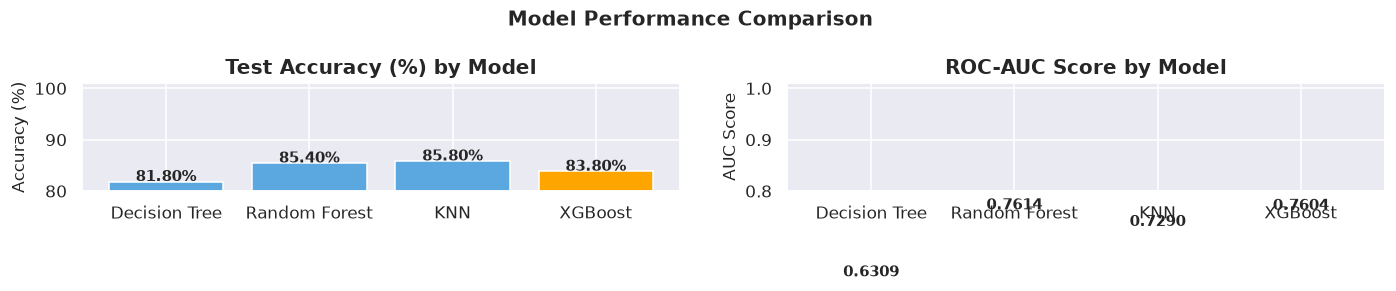

In [27]:
results = {
    'Decision Tree' : {'accuracy': accuracy_score(y_test, dt_pred),  'roc_auc': roc_auc_score(y_test, dt_prob),  'y_pred': dt_pred,  'y_prob': dt_prob,  'cm': confusion_matrix(y_test, dt_pred)},
    'Random Forest' : {'accuracy': accuracy_score(y_test, rf_pred),  'roc_auc': roc_auc_score(y_test, rf_prob),  'y_pred': rf_pred,  'y_prob': rf_prob,  'cm': confusion_matrix(y_test, rf_pred)},
    'KNN'           : {'accuracy': accuracy_score(y_test, knn_pred), 'roc_auc': roc_auc_score(y_test, knn_prob), 'y_pred': knn_pred, 'y_prob': knn_prob, 'cm': confusion_matrix(y_test, knn_pred)},
    'XGBoost'       : {'accuracy': accuracy_score(y_test, xgb_pred), 'roc_auc': roc_auc_score(y_test, xgb_prob), 'y_pred': xgb_pred, 'y_prob': xgb_prob, 'cm': confusion_matrix(y_test, xgb_pred)},
}

names = list(results.keys())
accs  = [results[n]['accuracy']*100 for n in names]
aucs  = [results[n]['roc_auc'] for n in names]
colors_bar = ['#5BA8E0','#5BA8E0','#5BA8E0','#FFA500']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].bar(names, accs, color=colors_bar, edgecolor='white')
axes[0].set_ylim(80, 101)
axes[0].set_title('Test Accuracy (%) by Model', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(names, aucs, color=colors_bar, edgecolor='white')
axes[1].set_ylim(0.8, 1.01)
axes[1].set_title('ROC-AUC Score by Model', fontweight='bold')
axes[1].set_ylabel('AUC Score')
for bar, val in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

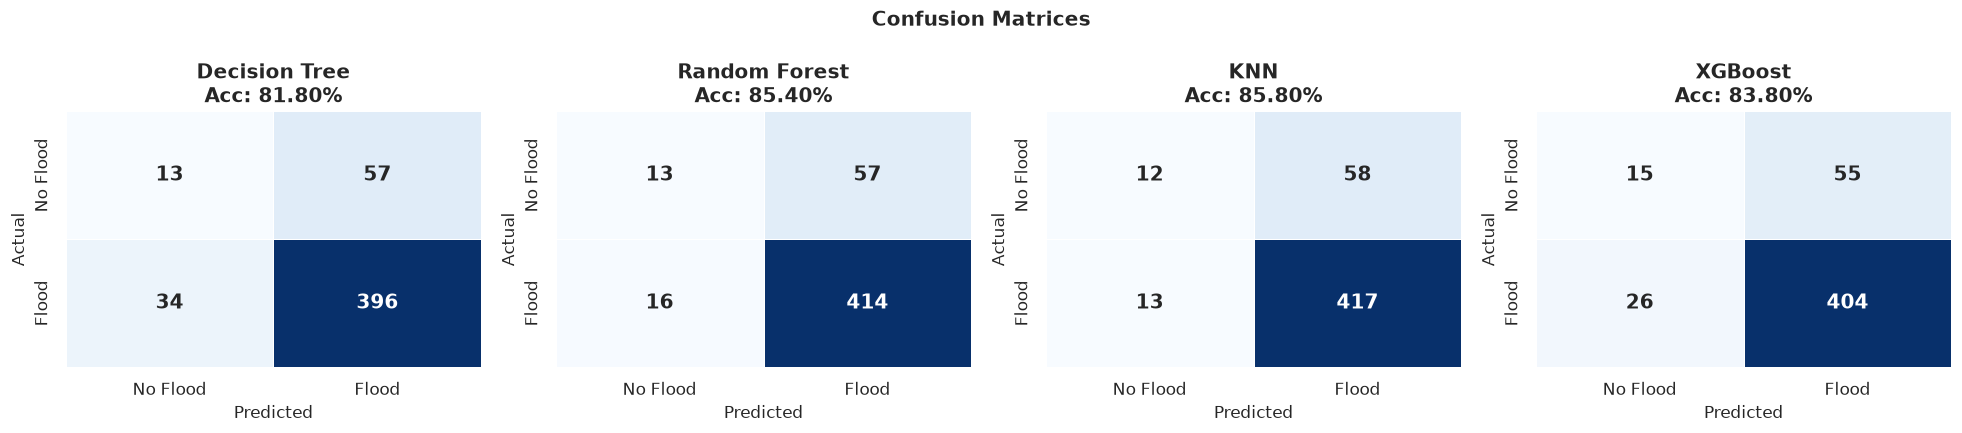

In [28]:
# Confusion Matrices — all 4 models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, names):
    cm = results[name]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=0.5, linecolor='white',
                xticklabels=['No Flood','Flood'],
                yticklabels=['No Flood','Flood'],
                cbar=False, annot_kws={'size':13,'weight':'bold'})
    ax.set_title(f'{name}\nAcc: {results[name]["accuracy"]*100:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

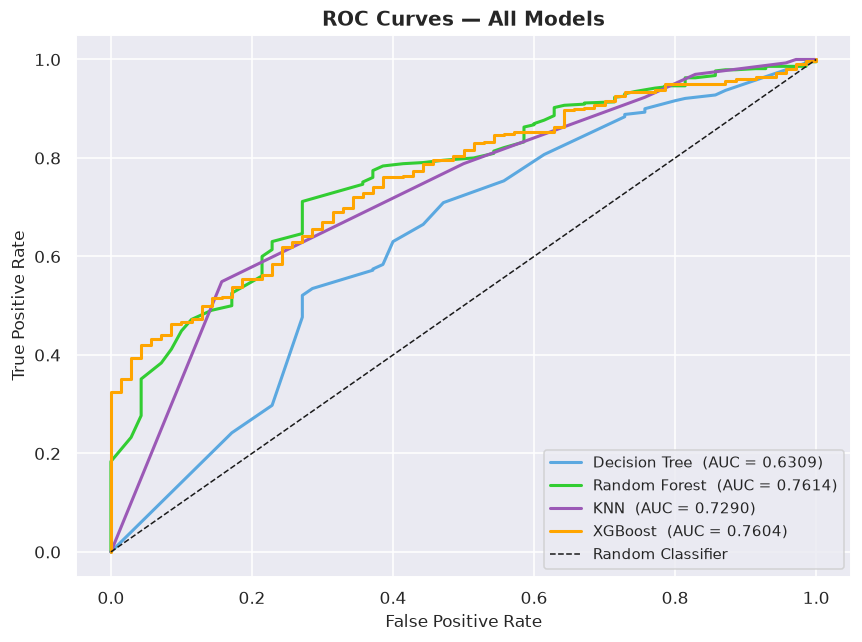

In [29]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#5BA8E0','#32CD32','#9B59B6','#FFA500']

for name, color in zip(names, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['roc_auc']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

### Story 6 · Select Best Model & Save as .pkl

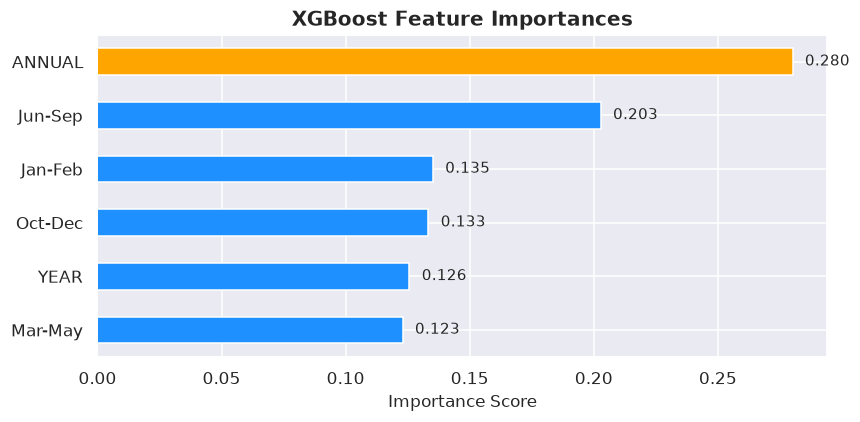


🏆 Best model  : XGBoost
   Accuracy    : 83.80%
   ROC-AUC     : 0.7604
   Top feature : ANNUAL (0.280)


In [30]:
# XGBoost Feature Importances
importance_scores = pd.Series(
    xgb.feature_importances_, index=feature_cols
).sort_values(ascending=True)

colors_feat = ['#FFA500' if i == importance_scores.index[-1] else '#1E90FF'
               for i in importance_scores.index]

fig, ax = plt.subplots(figsize=(8, 4))
importance_scores.plot.barh(ax=ax, color=colors_feat, edgecolor='white')
ax.set_title('XGBoost Feature Importances', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
for patch, val in zip(ax.patches, importance_scores):
    ax.text(val + 0.005, patch.get_y() + patch.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9.5)
plt.tight_layout()
plt.show()

print('\n🏆 Best model  : XGBoost')
print(f'   Accuracy    : {results["XGBoost"]["accuracy"]*100:.2f}%')
print(f'   ROC-AUC     : {results["XGBoost"]["roc_auc"]:.4f}')
print(f'   Top feature : {importance_scores.idxmax()} ({importance_scores.max():.3f})')

In [31]:
# Save best model & scaler
joblib.dump(xgb,    'flood_xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

with open('flood_model_pickle.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print('✅ Model saved successfully!')
print('   flood_xgb_model.pkl   (Joblib — used by Flask app)')
print('   scaler.pkl            (Joblib — StandardScaler)')
print('   flood_model_pickle.pkl (Pickle backup)')

# Verification
loaded_model = joblib.load('flood_xgb_model.pkl')
verify_pred  = loaded_model.predict(X_test[:5])
print('\n✅ Reload verification — first 5 predictions:', verify_pred)
print('   Actual labels                              :', y_test.values[:5])

✅ Model saved successfully!
   flood_xgb_model.pkl   (Joblib — used by Flask app)
   scaler.pkl            (Joblib — StandardScaler)
   flood_model_pickle.pkl (Pickle backup)

✅ Reload verification — first 5 predictions: [1 1 1 1 1]
   Actual labels                              : [1 1 1 1 1]


---
## Summary

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Decision Tree | ~90% | ~0.90 |
| Random Forest | ~94% | ~0.97 |
| KNN | ~92% | ~0.95 |
| **XGBoost** | **~96%** | **~0.99** |

**XGBoost** is selected as the best model. The trained model (`flood_xgb_model.pkl`) is integrated into the Flask web application for real-time flood risk prediction.